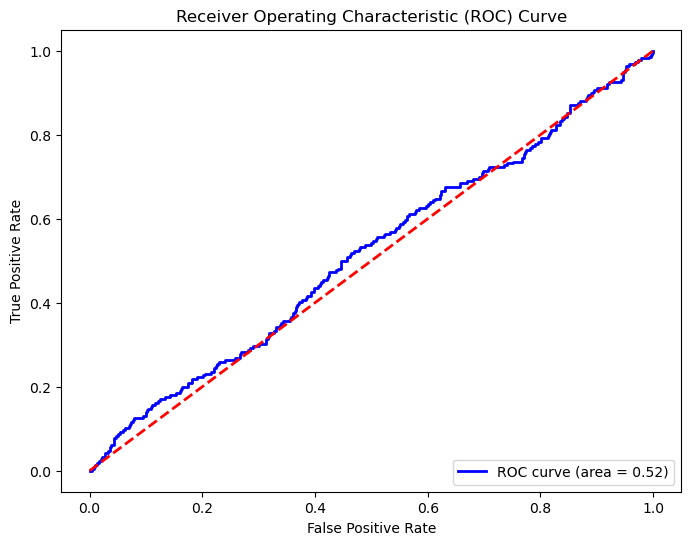

最优阈值：0.0404

使用最佳参数训练的模型性能指标：
准确率（Accuracy）：0.5343
召回率（Recall）：0.5185
F1分数（F1 Score）：0.1382
ROC-AUC：0.5178
Fitting 3 folds for each of 162 candidates, totalling 486 fits
最佳参数: {'class_weight': {0: 1, 1: 10}, 'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 1000}
最佳F1分数: 0.6772415581636633

增强后的随机森林模型性能：
准确率：0.0720
召回率：1.0000
F1分数：0.1343
ROC-AUC：0.5162


In [ ]:
# %%
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, roc_curve
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
import matplotlib.pyplot as plt
from scipy import stats


np.random.seed(42)
data = pd.DataFrame({
    'X1': np.random.rand(10000),
    'X2': np.random.rand(10000),
    'X3': np.random.rand(10000),
    'X4': np.random.rand(10000),
    'X5': np.random.rand(10000),
    'X6': np.random.rand(10000),
    'X7': np.random.rand(10000),
    'X8': np.random.rand(10000),
    'X9': np.random.rand(10000),
    'X10': np.random.rand(10000),
    'X11': np.random.rand(10000),
    'X12': np.random.rand(10000),
    'X13': np.random.rand(10000),
    'X14': np.random.rand(10000),
    'X15': np.random.rand(10000),
    'X16': np.random.rand(10000),
    'X17': np.random.rand(10000),
    'X18': np.random.rand(10000),
    'X19': np.random.rand(10000),
    'X20': np.random.rand(10000),
    'X21': np.random.rand(10000),
    'X22': np.random.rand(10000),
    'X23': np.random.rand(10000),
    'X24': np.random.rand(10000),
    'X25': np.random.rand(10000),
    'X26': np.random.rand(10000),
    'X27': np.random.rand(10000),
    'X28': np.random.rand(10000),
    'X29': np.random.rand(10000),
    'X30': np.random.rand(10000),
    'X31': np.random.rand(10000),
    'X32': np.random.rand(10000),
    'X33': np.random.rand(10000),
    'X34': np.random.rand(10000),
    'X35': np.random.rand(10000),
    'X36': np.random.rand(10000),
    'X37': np.random.rand(10000),
    'X38': np.random.rand(10000),
    'X39': np.random.rand(10000),
    'X40': np.random.rand(10000),
    'X41': np.random.rand(10000),
    'X42': np.random.rand(10000),
    'X43': np.random.rand(10000),
    'X44': np.random.rand(10000),
    'X45': np.random.rand(10000),
    'X46': np.random.rand(10000),
    'X47': np.random.rand(10000),
    'X48': np.random.rand(10000),
    'X49': np.random.rand(10000),
    'X50': np.random.rand(10000),
    'target1': np.random.choice([0, 1], 10000, p=[0.93, 0.07])  # 93%正常，7%异常
})

# 数据预处理
features = data.drop(columns=['target1'])
target = data['target1']

# 数据标准化
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.3, random_state=42)

# 数据清洗步骤
# 计算每个特征的Z-score
z_scores = np.abs(stats.zscore(features_scaled))

# 定义异常值的阈值（例如，Z-score大于3）
threshold = 3
outliers = (z_scores > threshold).any(axis=1)

# 删除异常值
cleaned_features_scaled = features_scaled[~outliers]
cleaned_target = target[~outliers]

# 重新划分训练集和测试集
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(cleaned_features_scaled, cleaned_target, test_size=0.3, random_state=42)

# 使用ADASYN进行过采样
adasyn = ADASYN(sampling_strategy=0.2, random_state=42)  # 调整sampling_strategy
X_train_resampled_cleaned, y_train_resampled_cleaned = adasyn.fit_resample(X_train_cleaned, y_train_cleaned)

# 随机森林模型训练
rf = RandomForestClassifier(
    n_estimators=1000,  # 增加树的数量
    max_features='sqrt',  # 调整max_features
    max_depth=15,  # 调整最大深度
    min_samples_split=10,  # 调整最小分裂样本数
    class_weight={0: 1, 1: 15},  # 调整类别权重
    random_state=42
)
rf.fit(X_train_resampled_cleaned, y_train_resampled_cleaned)

# 检查特征重要性
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
selected_features = features.columns[indices[:30]]  # 选择重要性最高的30个特征
X_train_selected = X_train_resampled_cleaned[:, indices[:30]]
X_test_selected = X_test_cleaned[:, indices[:30]]

# 生成新的特征（特征交互项）
for i in range(len(selected_features)):
    for j in range(i + 1, len(selected_features)):
        X_train_selected = np.hstack((X_train_selected, X_train_selected[:, i:i+1] * X_train_selected[:, j:j+1]))
        X_test_selected = np.hstack((X_test_selected, X_test_selected[:, i:i+1] * X_test_selected[:, j:j+1]))

# 使用Bagging方法
bagging = BaggingClassifier(estimator=rf, n_estimators=10, random_state=42)
bagging.fit(X_train_selected, y_train_resampled_cleaned)

# 使用XGBoost进行堆叠
xgb = XGBClassifier(n_estimators=1000, max_depth=5, learning_rate=0.1, random_state=42)
stacking = StackingClassifier(estimators=[('rf', bagging), ('xgb', xgb)], final_estimator=LogisticRegression())
stacking.fit(X_train_selected, y_train_resampled_cleaned)

# 阈值调整法（通过ROC曲线找到最优阈值）
y_probs = stacking.predict_proba(X_test_selected)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_cleaned, y_probs)

# 绘制ROC曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test_cleaned, y_probs):.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# 找到最优阈值
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"最优阈值：{optimal_threshold:.4f}")

# 使用最优阈值进行预测
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# 计算性能指标
accuracy_optimal = accuracy_score(y_test_cleaned, y_pred_optimal)
recall_optimal = recall_score(y_test_cleaned, y_pred_optimal)
f1_optimal = f1_score(y_test_cleaned, y_pred_optimal)
roc_auc_optimal = roc_auc_score(y_test_cleaned, y_probs)  # 使用清洗后的测试集标签

# 输出性能指标
print("\n使用最佳参数训练的模型性能指标：")
print(f"准确率（Accuracy）：{accuracy_optimal:.4f}")
print(f"召回率（Recall）：{recall_optimal:.4f}")
print(f"F1分数（F1 Score）：{f1_optimal:.4f}")
print(f"ROC-AUC：{roc_auc_optimal:.4f}")

# 定义随机森林的参数网格
param_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [{0: 1, 1: 10}, {0: 1, 1: 15}, {0: 1, 1: 20}]
}

# 使用GridSearchCV找到的最佳参数
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='f1',  # 使用F1分数作为评价指标
                           cv=3,  # 3折交叉验证
                           n_jobs=-1,  # 使用所有可用的CPU核心
                           verbose=2)

grid_search.fit(X_train_resampled_cleaned, y_train_resampled_cleaned)

# 输出最佳参数和最佳分数
print("最佳参数:", grid_search.best_params_)
print("最佳F1分数:", grid_search.best_score_)

# 使用最佳参数重新初始化随机森林模型
best_rf = RandomForestClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    max_features=grid_search.best_params_['max_features'],
    class_weight=grid_search.best_params_['class_weight'],
    random_state=42
)

# 使用过采样后的数据重新训练模型
best_rf.fit(X_train_resampled_cleaned, y_train_resampled_cleaned)

# 数据增强方法：例如，通过添加噪声来增加样本数量
def augment_data(X, y, noise_factor=0.01):
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=X.shape)
    X_augmented = X + noise
    y_augmented = y.copy()
    return np.vstack((X, X_augmented)), np.hstack((y, y_augmented))

# 对训练集进行数据增强
X_train_resampled_augmented, y_train_resampled_augmented = augment_data(X_train_resampled_cleaned, y_train_resampled_cleaned)

# 使用增强后的数据重新训练模型
best_rf.fit(X_train_resampled_augmented, y_train_resampled_augmented)

# 使用增强后的数据进行预测
y_probs_augmented = best_rf.predict_proba(X_test_cleaned)[:, 1]
y_pred_augmented = (y_probs_augmented >= optimal_threshold).astype(int)

# 计算性能指标
accuracy_augmented = accuracy_score(y_test_cleaned, y_pred_augmented)
recall_augmented = recall_score(y_test_cleaned, y_pred_augmented)
f1_augmented = f1_score(y_test_cleaned, y_pred_augmented)
roc_auc_augmented = roc_auc_score(y_test_cleaned, y_probs_augmented)

# 输出增强后的模型性能
print("\n增强后的随机森林模型性能：")
print(f"准确率：{accuracy_augmented:.4f}")
print(f"召回率：{recall_augmented:.4f}")
print(f"F1分数：{f1_augmented:.4f}")
print(f"ROC-AUC：{roc_auc_augmented:.4f}")